In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense


Shakespeare text dataset

In [2]:
path_to_file = tf.keras.utils.get_file(
    'shakespeare.txt',
    'https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt'
)

text = open(path_to_file, 'rb').read().decode(encoding='utf-8')
text = text.lower()
text[:500]

"first citizen:\nbefore we proceed any further, hear me speak.\n\nall:\nspeak, speak.\n\nfirst citizen:\nyou are all resolved rather to die than to famish?\n\nall:\nresolved. resolved.\n\nfirst citizen:\nfirst, you know caius marcius is chief enemy to the people.\n\nall:\nwe know't, we know't.\n\nfirst citizen:\nlet us kill him, and we'll have corn at our own price.\nis't a verdict?\n\nall:\nno more talking on't; let it be done: away, away!\n\nsecond citizen:\none word, good citizens.\n\nfirst citizen:\nwe are accounted poor"

Tokenization
    Creating tokenizer as object then fit tokenizer on text
    total unique words

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])
total_words = len(tokenizer.word_index) + 1
total_words

12633

In [4]:
tokenizer.word_index

{'the': 1,
 'and': 2,
 'to': 3,
 'i': 4,
 'of': 5,
 'you': 6,
 'my': 7,
 'a': 8,
 'that': 9,
 'in': 10,
 'is': 11,
 'not': 12,
 'for': 13,
 'with': 14,
 'me': 15,
 'it': 16,
 'be': 17,
 'your': 18,
 'his': 19,
 'but': 20,
 'this': 21,
 'he': 22,
 'have': 23,
 'as': 24,
 'thou': 25,
 'him': 26,
 'so': 27,
 'what': 28,
 'thy': 29,
 'will': 30,
 'by': 31,
 'no': 32,
 'all': 33,
 'king': 34,
 'we': 35,
 'shall': 36,
 'her': 37,
 'if': 38,
 'our': 39,
 'are': 40,
 'do': 41,
 'thee': 42,
 'lord': 43,
 'now': 44,
 'on': 45,
 'good': 46,
 'from': 47,
 'come': 48,
 'sir': 49,
 'or': 50,
 'which': 51,
 'more': 52,
 'then': 53,
 'at': 54,
 'o': 55,
 'would': 56,
 'was': 57,
 'they': 58,
 'how': 59,
 'well': 60,
 'here': 61,
 'she': 62,
 'than': 63,
 'their': 64,
 'them': 65,
 'duke': 66,
 'am': 67,
 'hath': 68,
 'say': 69,
 'let': 70,
 'when': 71,
 'one': 72,
 "i'll": 73,
 'go': 74,
 'love': 75,
 'were': 76,
 'may': 77,
 'us': 78,
 'make': 79,
 'like': 80,
 'upon': 81,
 'yet': 82,
 'richard': 83,

Creating input sequences
    Store the input sequences and converting text to lines
    Generating sequences

In [5]:
input_sequences = []
lines = text.split('\n')

for line in lines:
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

len(input_sequences)

171312

Applying Padding to Sequences
    The generated sequences have different lengths.
    Deep learning models require all input sequences to have the same length during training.
    Padding is used to add zeros to shorter sequences.
    Pre-padding is preferred in NLP because the latest words remain closer to the prediction point, which helps the LSTM model learn better contextual relationships.

In [6]:
max_sequence_len = max([len(x) for x in input_sequences])

input_sequences = np.array(
    pad_sequences(
        input_sequences,
        maxlen=max_sequence_len,
        padding='pre'
    )
)

input_sequences.shape

(171312, 16)

Separation of Features and Labels
    The model learns to predict the next word based on previous words.
X -> Input features
y -> Target output

In [7]:
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

# Convert output label into categorical format
y = tf.keras.utils.to_categorical(y, num_classes=total_words)

X.shape, y.shape

((171312, 15), (171312, 12633))

LSTM Model 

The architecture contains 3 layers as:
    Embedding Layer
        Converts words into dense vector representations.
        Helps the model understand semantic relationships between words.
    LSTM Layer
        Learns sequential dependencies from text data.
        Remembers important previous information for prediction.
    Dense Output Layer
        Predicts the probability of the next word
        Uses softmax activation for multi-class classification.

In [8]:
model = Sequential()

model.add(
    Embedding(
        input_dim=total_words,
        output_dim=100,
        input_shape=(max_sequence_len - 1,)
    )
)

model.add(LSTM(150))

model.add(Dense(total_words, activation='softmax'))

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

C:\Users\roopt\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\embedding.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 15, 100)        │     1,263,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 150)            │       150,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 12633)          │     1,907,583 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,321,483 (12.67 MB)

 Trainable params: 3,321,483 (12.67 MB)

 Non-trainable params: 0 (0.00 B)

Trainig the Model

In [10]:
history = model.fit(X, y, epochs=100, batch_size=128, verbose=1)

Epoch 1/100
1339/1339 ━━━━━━━━━━━━━━━━━━━━ 66s 48ms/step - accuracy: 0.0327 - loss: 7.1203
Epoch 2/100
1339/1339 ━━━━━━━━━━━━━━━━━━━━ 63s 47ms/step - accuracy: 0.0623 - loss: 6.3726
Epoch 3/100
1339/1339 ━━━━━━━━━━━━━━━━━━━━ 88s 66ms/step - accuracy: 0.0887 - loss: 6.0092
Epoch 4/100
1339/1339 ━━━━━━━━━━━━━━━━━━━━ 93s 70ms/step - accuracy: 0.1020 - loss: 5.7611
Epoch 5/100
1339/1339 ━━━━━━━━━━━━━━━━━━━━ 94s 70ms/step - accuracy: 0.1100 - loss: 5.5499
Epoch 6/100
1339/1339 ━━━━━━━━━━━━━━━━━━━━ 93s 69ms/step - accuracy: 0.1159 - loss: 5.3769
Epoch 7/100
1339/1339 ━━━━━━━━━━━━━━━━━━━━ 94s 70ms/step - accuracy: 0.1253 - loss: 5.1827
Epoch 8/100
1339/1339 ━━━━━━━━━━━━━━━━━━━━ 83s 62ms/step - accuracy: 0.1320 - loss: 5.0172
Epoch 9/100
1339/1339 ━━━━━━━━━━━━━━━━━━━━ 82s 61ms/step - accuracy: 0.1424 - loss: 4.8424
Epoch 10/100
1339/1339 ━━━━━━━━━━━━━━━━━━━━ 81s 60ms/step - accuracy: 0.1512 - loss: 4.7015
Epoch 11/100
1339/1339 ━━━━━━━━━━━━━━━━━━━━ 83s 62ms/step - accuracy: 0.1642 - loss: 4.54

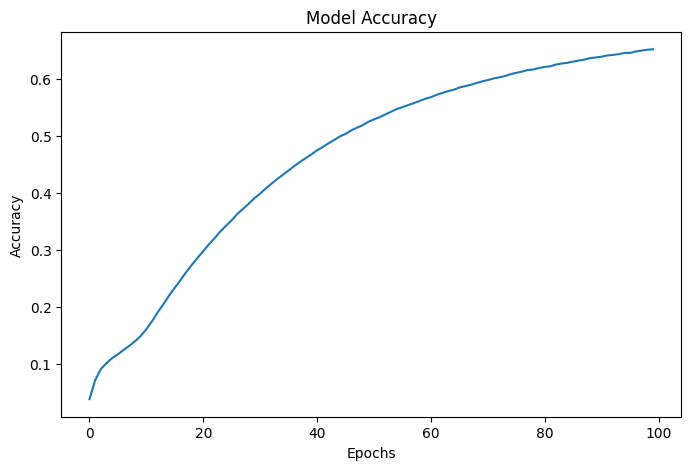

In [11]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.show()

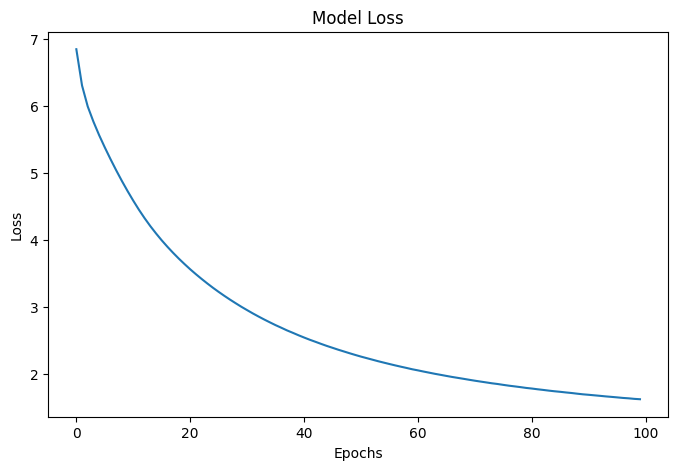

In [12]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.show()

In [13]:
# Function to generate text

def generate_text(seed_text, next_words):
    
    for _ in range(next_words):
        
        # Convert text into token sequence
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        
        # Apply padding
        token_list = pad_sequences(
            [token_list],
            maxlen=max_sequence_len - 1,
            padding='pre'
        )
        
        # Predict next word
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]
        
        output_word = ""
        
        # Find predicted word
        for word, index in tokenizer.word_index.items():
            
            if index == predicted:
                
                output_word = word
                break
        
        # Append predicted word
        seed_text += " " + output_word
    
    return seed_text

In [14]:
print(generate_text("to be", 10))

to be revenged on him that loveth you rather see me boy


In [15]:
print(generate_text("the king", 10))

the king shall be contented must he lose it and nurse them


In [16]:
print(generate_text("i love", 10))

i love thee not a jar o' the clock behind it he


In [17]:
model.save("text_generation_lstm_model.h5")